# Sesión 2 · Laboratorio
## ACF/PACF, gaps y manejo temporal sobre ClimaLab

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

---

### Objetivos del laboratorio

1. Manejar correctamente timestamps y zonas horarias en pandas.
2. **Detectar gaps** explícitos e implícitos en una serie meteorológica real.
3. Aplicar control de calidad básico (rangos físicos, saturación de sensor).
4. Calcular **ACF y PACF** con `statsmodels` sobre la serie de temperatura.
5. **Identificar visualmente** las periodicidades diaria y anual a partir de la ACF.
6. Aplicar ACF/PACF sobre los **residuales** de una descomposición STL para validar el modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import STL

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Carga

In [2]:
f = "../data/ClimaLab_2023-05-31_2025-06-20.parquet"

df = pd.read_parquet(f)
df.head()

variable,dhi,dni,ghi,p_atm,rain_acc,rh,solar_altitude,tdb,uv,wd,ws
date,,,,,,,,,,,
2023-05-31 18:59:00,7.391,21.710,9.66,641.4001,0.0,60.18,1.867189,27.78,0.0,336.6,0.0
2023-05-31 19:00:00,7.020,0.000,9.26,641.4001,0.0,60.46,1.663787,27.73,0.0,344.7,0.0
2023-05-31 19:01:00,6.603,2.945,8.83,641.3997,0.0,60.42,1.461872,27.71,0.0,319.1,0.0
2023-05-31 19:02:00,6.262,3.643,8.46,641.4001,0.0,60.81,1.261586,27.69,0.0,322.8,0.0
2023-05-31 19:03:00,5.952,7.574,8.02,641.3999,0.0,60.45,1.063073,27.65,0.0,346.9,0.0


<Axes: xlabel='date'>

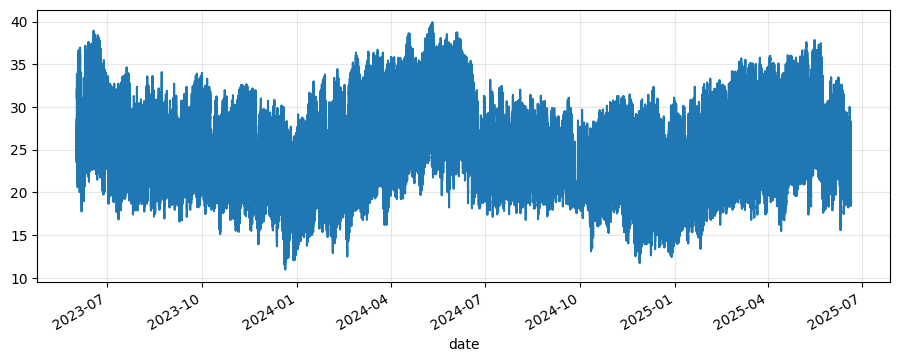

In [32]:
df.tdb.plot()

In [3]:
print(f"Forma del DataFrame: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Período: {df.index.min()} a {df.index.max()}")
print(f"Frecuencia esperada: 1 min")
print(f"Tipo de índice: {type(df.index).__name__}, tz = {df.index.tz}")

Forma del DataFrame: 1,076,768 filas × 11 columnas
Período: 2023-05-31 18:59:00 a 2025-06-20 00:00:00
Frecuencia esperada: 1 min
Tipo de índice: DatetimeIndex, tz = None


## 2. Manejo de timestamps y zonas horarias

El índice viene **naive** (`tz=None`). Recordemos: ClimaLab guarda hora local de Morelos (UTC−6, sin DST). Hagamos explícito ese contexto.

In [4]:
# Anclamos la zona horaria. Esto NO modifica los timestamps,
# sólo les pega una etiqueta. La diferencia con tz_convert es importante:
#  - tz_localize("America/Mexico_City"):  "estos números YA estaban en hora local"
#  - tz_convert("America/Mexico_City"):    "estos números están en UTC, conviértelos"
df = df.tz_localize("America/Mexico_City", nonexistent="shift_forward", ambiguous="NaT")

print("Índice ahora con tz:", df.index.tz)
print("Primer timestamp:    ", df.index[0])
print("Último timestamp:    ", df.index[-1])

Índice ahora con tz: America/Mexico_City
Primer timestamp:     2023-05-31 18:59:00-06:00
Último timestamp:     2025-06-20 00:00:00-06:00


### ¿Por qué importa tanto?

Si tratamos UTC como local (o viceversa), el ciclo diario aparecerá *desplazado*: el máximo diurno se moverá 6 horas y la descomposición saldrá mal centrada. Es el error más común en análisis meteorológico y la razón por la que vale la pena dedicarle 30 segundos cada vez que se carga un dataset.

## 3. Detección de gaps

Hay dos clases de gaps a buscar:

1. **Filas faltantes** (el índice salta).
2. **`NaN` dentro de filas existentes** (la fila está, el valor no).

In [5]:
# 3.1 Filas faltantes: comparamos el índice real con un rango completo a 1 min
esperado = pd.date_range(df.index.min(), df.index.max(), freq="1min", tz=df.index.tz)
faltantes_idx = esperado.difference(df.index)

print(f"Filas esperadas: {len(esperado):,}")
print(f"Filas presentes: {len(df):,}")
print(f"Filas faltantes: {len(faltantes_idx):,}  ({100*len(faltantes_idx)/len(esperado):.2f}%)")

Filas esperadas: 1,080,302
Filas presentes: 1,076,768
Filas faltantes: 3,534  (0.33%)


In [6]:
# 3.2 ¿Cómo se distribuyen esos gaps en el tiempo? ¿Son cortos y dispersos
#     o largos y concentrados?
if len(faltantes_idx) > 0:
    # Agrupamos timestamps faltantes consecutivos en bloques (gap "real")
    faltantes_serie = pd.Series(1, index=faltantes_idx)
    bloques = (faltantes_serie.index.to_series().diff() != pd.Timedelta("1min")).cumsum()
    duraciones = faltantes_serie.groupby(bloques).size()  # minutos por bloque
    print(f"Número de bloques de gap: {len(duraciones):,}")
    print(f"Mediana del bloque (min): {duraciones.median():.0f}")
    print(f"Bloque más largo (min):   {duraciones.max():,}")
    print()
    print("Top-5 gaps más largos:")
    top = duraciones.sort_values(ascending=False).head(5)
    for b, dur in top.items():
        inicio = faltantes_serie[bloques == b].index[0]
        print(f"  {inicio}  →  {dur:,} min  ({dur/60:.1f} h)")
else:
    print("Sin filas faltantes.")

Número de bloques de gap: 233
Mediana del bloque (min): 1
Bloque más largo (min):   624

Top-5 gaps más largos:
  2024-02-17 21:12:00-06:00  →  624 min  (10.4 h)
  2023-05-31 22:00:00-06:00  →  573 min  (9.6 h)
  2025-04-26 04:32:00-06:00  →  132 min  (2.2 h)
  2025-05-06 04:28:00-06:00  →  126 min  (2.1 h)
  2025-05-01 04:39:00-06:00  →  125 min  (2.1 h)


In [7]:
# 3.3 NaN por columna (la otra cara de los gaps)
faltantes_col = df.isna().sum()
porcentajes = (faltantes_col / len(df) * 100).round(1)
pd.DataFrame({"NaN": faltantes_col, "%": porcentajes}).sort_values("%", ascending=False)

,NaN,%
variable,,
dni,534987,49.7
ghi,533579,49.6
dhi,533536,49.5
p_atm,0,0.0
rain_acc,0,0.0
rh,0,0.0
solar_altitude,0,0.0
tdb,0,0.0
uv,0,0.0


**Recordatorio del lab anterior.** `dhi`, `dni`, `ghi` tienen ~50 % de `NaN` porque sólo se reportan de día. No es un defecto, es estructural. `tdb` (temperatura) está casi completa: la usaremos como caso base para ACF/PACF.

## 4. Control de calidad básico

Antes de calcular ACF, los cuatro chequeos del oficio: rangos físicos, saturación, duplicados de tiempo, y outliers gruesos.

In [8]:
# 4.1 Rangos físicos plausibles para Morelos
limites = {
    "tdb":   (-5,   50),
    "rh":    (0,   100),
    "p_atm": (800, 900),    # Temixco está a ~1280 m, ~870 hPa típica
    "ws":    (0,    40),
    "ghi":   (0,  1500),
}

resumen = []
for var, (lo, hi) in limites.items():
    s = df[var].dropna()
    fuera = ((s < lo) | (s > hi)).sum()
    resumen.append({"var": var, "min": s.min(), "max": s.max(),
                    "fuera_rango": fuera, "% fuera": 100 * fuera / len(s)})
pd.DataFrame(resumen).round(2)

,var,min,max,fuera_rango,% fuera
0,tdb,10.98,39.93,0,0.00
1,rh,-8.19,138.50,117,0.01
2,p_atm,443.27,1593.04,199705,18.55
3,ws,0.00,18.28,0,0.00
4,ghi,0.00,1360.00,0,0.00


Confirmamos lo del lab anterior: `p_atm` y `rh` tienen valores físicamente imposibles. Para esta sesión los marcaremos como `NaN` en una copia limpia.

In [9]:
df_qc = df.copy()
for var, (lo, hi) in limites.items():
    mask_fuera = (df_qc[var] < lo) | (df_qc[var] > hi)
    df_qc.loc[mask_fuera, var] = np.nan
    if mask_fuera.sum():
        print(f"  {var}: marcados {mask_fuera.sum():,} valores fuera de [{lo}, {hi}]")

  rh: marcados 117 valores fuera de [0, 100]
  p_atm: marcados 199,705 valores fuera de [800, 900]


In [10]:
# 4.2 Saturación: tramos donde el sensor reporta el mismo valor exacto
#     durante muchos minutos seguidos. Buscamos en tdb (no debería ocurrir).
tdb = df_qc["tdb"].dropna()
runs = (tdb != tdb.shift()).cumsum()
duraciones_run = tdb.groupby(runs).size()
print(f"Run más largo de tdb constante: {duraciones_run.max()} minutos")
print(f"Runs de >30 min con tdb idéntica: {(duraciones_run > 30).sum()}")

Run más largo de tdb constante: 10 minutos
Runs de >30 min con tdb idéntica: 0


In [11]:
# 4.3 Timestamps duplicados
duplicados = df.index.duplicated().sum()
print(f"Timestamps duplicados en el índice: {duplicados}")

Timestamps duplicados en el índice: 0


## 5. ACF y PACF a resolución horaria — ciclo diario

Con 1 millón de filas a 1 min, calcular ACF directamente es lento e innecesario para ver el ciclo diario. Resampleamos a 1 hora y nos fijamos en hasta 72 rezagos (3 días).

In [44]:
horario = df_qc.resample("h").mean(numeric_only=True)
tdb_h = horario["tdb"].dropna()

print(f"tdb horaria: {len(tdb_h):,} puntos")
print(f"NaN restantes: {tdb_h.isna().sum()}")

tdb horaria: 17,982 puntos
NaN restantes: 0


In [45]:
tdb

date
2023-05-31 18:59:00-06:00    27.78
2023-05-31 19:00:00-06:00    27.73
2023-05-31 19:01:00-06:00    27.71
2023-05-31 19:02:00-06:00    27.69
2023-05-31 19:03:00-06:00    27.65
                             ...  
2025-06-19 23:56:00-06:00    18.88
2025-06-19 23:57:00-06:00    18.89
2025-06-19 23:58:00-06:00    18.87
2025-06-19 23:59:00-06:00    18.87
2025-06-20 00:00:00-06:00    18.87
Name: tdb, Length: 1076768, dtype: float64

In [46]:
60*24*365

525600

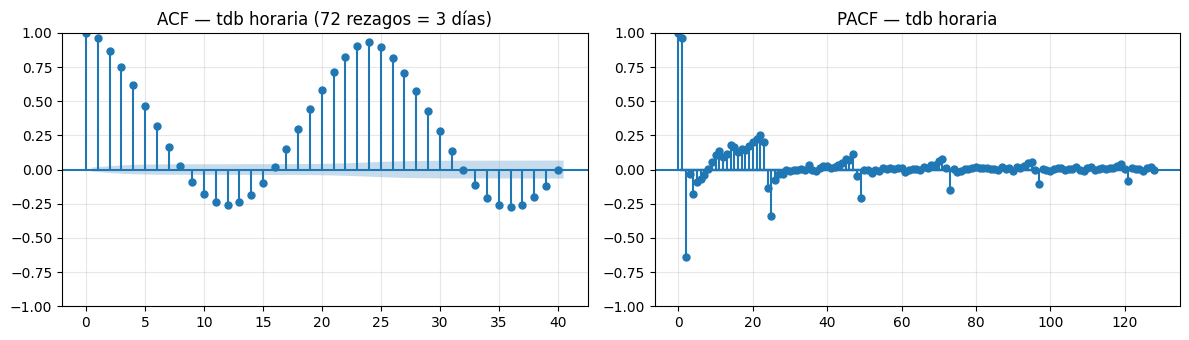

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(tdb_h, lags=40, ax=axes[0])
axes[0].set_title("ACF — tdb horaria (72 rezagos = 3 días)")
plot_pacf(tdb_h, lags=128, ax=axes[1], method="ywm")
axes[1].set_title("PACF — tdb horaria")
plt.tight_layout(); plt.show()

### Lo que vemos

- **Picos en la ACF cada 24 rezagos** (24, 48, 72): firma inequívoca del ciclo diario.
- La ACF **no decae** rápido a cero: oscila. Eso confirma que la serie *no* es estacionaria — la estacionalidad la hace volver una y otra vez al mismo nivel.
- La PACF tiene un pico fuerte en lag 1 (la temperatura de "ahora" está casi determinada por la de "hace 1 hora"), y picos secundarios cerca de 24.

> **Conclusión práctica.** Si vamos a modelar `tdb` con ARIMA, necesitamos **diferenciación estacional** ($s=24$) para volverla estacionaria. Eso es la $D$ de SARIMA, que veremos en la sesión 7.

## 6. ACF a resolución diaria — ciclo anual

Ahora resampleamos a un día y miramos hasta 400 rezagos (más de un año).

In [14]:
diario = df_qc.resample("1D").mean(numeric_only=True)
tdb_d = diario["tdb"].dropna()
print(f"tdb diaria: {len(tdb_d):,} puntos")

tdb diaria: 752 puntos


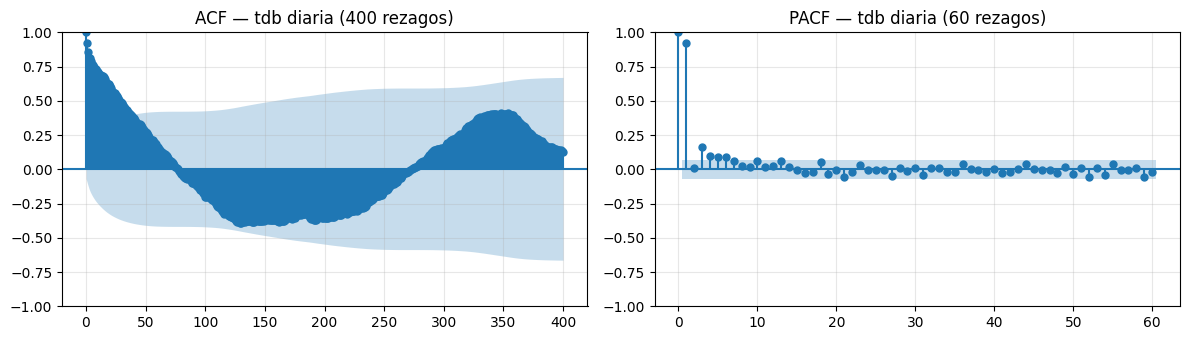

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(tdb_d, lags=400, ax=axes[0])
axes[0].set_title("ACF — tdb diaria (400 rezagos)")
plot_pacf(tdb_d, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — tdb diaria (60 rezagos)")
plt.tight_layout(); plt.show()

### Lo que vemos

- En la ACF diaria, la correlación cae los primeros días, vuelve a subir alrededor del rezago **365**. Ese es el **ciclo anual**: la temperatura de hoy se parece a la de hace exactamente un año.
- En los rezagos cercanos a 180 hay correlación **negativa**: hoy se parece *poco* a hace 6 meses (que es la estación opuesta).
- La PACF en los primeros rezagos ya muestra que `tdb` diaria tiene memoria de varios días — un AR de orden alto o un ARMA es el modelo natural.

## 7. ACF sobre los residuales de STL

Una de las pruebas más útiles: **ajustamos un modelo y miramos si los residuales se ven como ruido blanco**. Si la ACF de los residuales sale plana, el modelo capturó la estructura; si quedan picos, hay algo más que explicar.

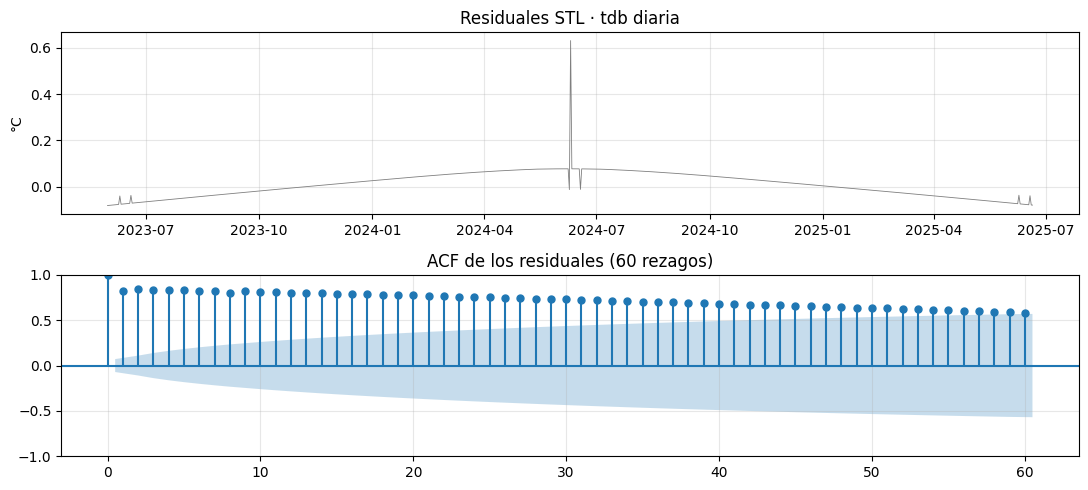

In [16]:
# Re-aplicamos STL diaria con período = 365 (igual que en la sesión 1)
stl = STL(tdb_d, period=365, robust=True).fit()
resid = stl.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=False)
axes[0].plot(resid.index, resid.values, lw=0.6, color="C7")
axes[0].set_title("Residuales STL · tdb diaria")
axes[0].set_ylabel("°C")

plot_acf(resid, lags=60, ax=axes[1])
axes[1].set_title("ACF de los residuales (60 rezagos)")
plt.tight_layout(); plt.show()

### Interpretación

- Si la ACF de los residuales está mayoritariamente dentro de las bandas → STL hizo bien su trabajo.
- Si quedan picos significativos en los primeros rezagos → hay autocorrelación de corto plazo no capturada (típico en datos diarios: el "estado" del clima persiste varios días). Esto es una **oportunidad de modelar el residual** con un AR de orden bajo.

Volveremos a este flujo en el Bloque 4: anomalías como puntos cuyo residual no encaja en lo que la ACF esperaría.

## 8. Periodicidad escondida: ¿la veríamos sin saber que está?

Pregunta provocadora: si **no supiéramos** que el ciclo diario tiene período 24, ¿la ACF nos lo descubriría?

Tomemos un mes de tdb horaria y simulemos a alguien que no sabe nada del fenómeno.

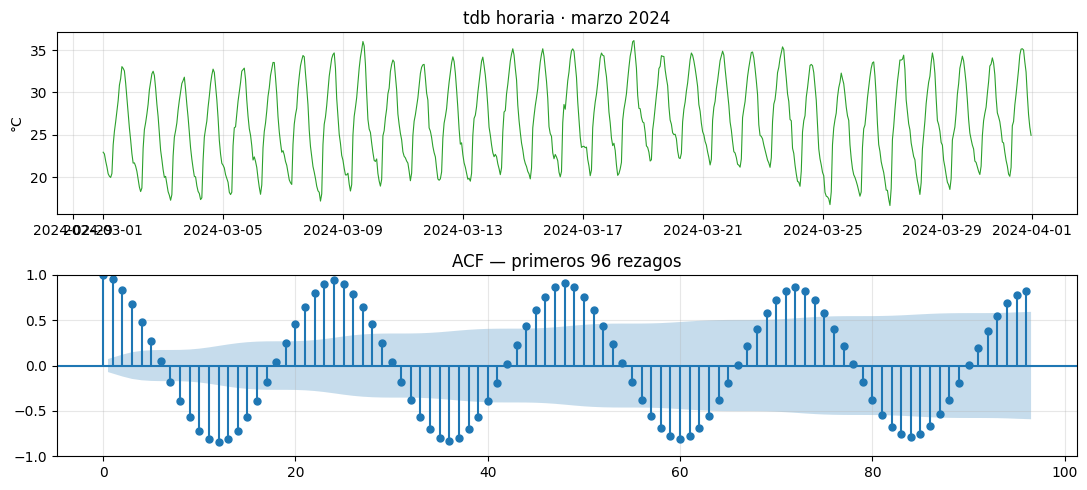

Primer pico local de la ACF en rezago: 24


In [17]:
tdb_mes = horario["tdb"].loc["2024-03"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(tdb_mes.index, tdb_mes.values, lw=0.8, color="C2")
axes[0].set_title("tdb horaria · marzo 2024")
axes[0].set_ylabel("°C")

plot_acf(tdb_mes, lags=96, ax=axes[1])  # 96 h = 4 días
axes[1].set_title("ACF — primeros 96 rezagos")
plt.tight_layout(); plt.show()

# Y, programáticamente, ¿en qué rezago está el primer máximo local de la ACF?
acf_vals = acf(tdb_mes, nlags=96)
# Buscamos el primer pico después del lag 0
diffs = np.diff(acf_vals)
picos = np.where((diffs[:-1] > 0) & (diffs[1:] < 0))[0] + 1
print(f"Primer pico local de la ACF en rezago: {picos[0]}")

**Sin asumir nada del fenómeno**, la ACF nos entrega el período 24. Esto es lo que la hace tan poderosa para series donde no conocemos a priori los ciclos (procesos industriales, biomédicos, financieros).

## 9. Ejercicio guiado (15 min, en parejas)

Repite el flujo para la **humedad relativa** (`rh`) ya filtrada por QC:

1. Resampleo horario y diario.
2. ACF/PACF horaria con 72 rezagos.
3. ACF diaria con 400 rezagos.
4. STL diaria + ACF de residuales.

**Discusión:**

- ¿La estacionalidad diaria de `rh` es tan limpia como la de `tdb`?
- ¿En qué meses se observan los máximos de humedad? ¿Coincide con la temporada de lluvias en Morelos (junio–octubre)?
- ¿Los residuales de STL para `rh` se ven más o menos "blancos" que los de `tdb`?

```python
# Plantilla
rh_h = horario["rh"].dropna()
rh_d = diario["rh"].dropna()

# 1) ACF/PACF horaria
# fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
# plot_acf(rh_h, lags=72, ax=axes[0])
# plot_pacf(rh_h, lags=72, ax=axes[1], method="ywm")
# ...
```

In [18]:
# Tu código aquí
rh_h = horario["rh"].dropna()
rh_d = diario["rh"].dropna()


## 10. Reto para casa

Toma la serie horaria de **GHI** (irradiancia global horizontal) **sólo durante horas con sol** (filtra por `solar_altitude > 0`). Sobre esa serie ya filtrada:

1. Calcula la ACF a 200 rezagos.
2. ¿Aparece un ciclo de período 24? ¿Por qué sí o por qué no?
3. ¿Qué pasa si en lugar de filtrar por altura solar, **resampleas a diario**?

Entrega un notebook con tus gráficas y una conclusión de 3 renglones.

## 11. Síntesis de la sesión

| Tarea | Herramienta |
|-------|-------------|
| Anclar zona horaria | `df.tz_localize("America/Mexico_City")` |
| Detectar filas faltantes | `pd.date_range(...).difference(df.index)` |
| Marcar valores fuera de rango | máscara booleana → `NaN` |
| ACF/PACF | `statsmodels.graphics.tsaplots.plot_acf, plot_pacf` |
| Identificar ciclo diario | pico de ACF en rezago 24 (datos horarios) |
| Identificar ciclo anual | pico de ACF en rezago 365 (datos diarios) |
| Validar un modelo | ACF de los residuales debe ser ≈ ruido blanco |

> **Tres reflejos del oficio que te llevas de esta sesión.**
>
> 1. **Antes de cualquier modelo, busca gaps y rangos imposibles.**
> 2. **Antes de modelar, mira la ACF.** Te dice si tu serie es estacionaria, qué períodos tiene y qué orden ARIMA tentativo probar.
> 3. **Después de modelar, mira la ACF de los residuales.** Si no es plana, tu modelo es mejorable.